# Лабораторна робота №2 “Пошук асоціативних правил”
**Мета.** Ознайомитися з принципами **побудови асоціативних правил** (association rule mining) на реальних даних користувацьких уподобань. Навчитись виконувати пошук **частих наборів елементів (frequent itemsets)** і формувати **асоціативні правила** за допомогою метрик _support_, _confidence_ і _lift_ на основі набору даних **MovieLens Small**. Розвинути навички попередньої обробки даних, перетворення даних у транзакційний формат і інтерпретації результатів.

## Хід роботи

Імпортуємо бібліотеки

In [1]:
import os
import shutil
import urllib.request
import zipfile
import pandas as pd

In [2]:
# Налаштування виводу
pd.set_option("display.max_colwidth", None)

### Завантаження та підготовка даних
Створимо папку `tmp/` для тимчасових файлів.

In [3]:
if not os.path.exists("tmp"):
    os.makedirs("tmp")

Викачаємо та розпакуємо архів з даними.

In [4]:
urllib.request.urlretrieve("https://files.grouplens.org/datasets/movielens/ml-latest-small.zip", "tmp/ml-latest-small.zip")

with zipfile.ZipFile("tmp/ml-latest-small.zip", "r") as zip_ref:
    zip_ref.extractall("tmp")

Завантажимо таблиці `ratings.csv` і `movies.csv` за допомогою `pandas` та об'єднаємо їх.

In [5]:
movies = pd.read_csv("tmp/ml-latest-small/movies.csv")
ratings = pd.read_csv("tmp/ml-latest-small/ratings.csv")

merged = pd.merge(movies, ratings, on="movieId")
merged

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483
...,...,...,...,...,...,...
100831,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,184,4.0,1537109082
100832,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,184,3.5,1537109545
100833,193585,Flint (2017),Drama,184,3.5,1537109805
100834,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,184,3.5,1537110021


Оберемо лише оцінки >=4.

In [6]:
filtered = merged.drop(merged[merged.rating < 4].index)
filtered

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483
6,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,19,4.0,965705637
...,...,...,...,...,...,...
100825,191005,Gintama (2017),Action|Adventure|Comedy|Sci-Fi,184,4.5,1537109489
100828,193571,Silver Spoon (2014),Comedy|Drama,184,4.0,1537099392
100829,193573,Love Live! The School Idol Movie (2015),Animation,184,4.0,1537099811
100831,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,184,4.0,1537109082


Знайдемо кількість унікальних користувачів і фільмів.

In [7]:
unique_movies_merged = merged["movieId"].unique()
unique_users_merged = merged["userId"].unique()
print(f"Усі фільми: {len(unique_movies_merged)} фільмів, {len(unique_users_merged)} користувачів")

unique_movies_filtered = filtered["movieId"].unique()
unique_users_filtered = filtered["userId"].unique()
print(f"Улюблені фільми: {len(unique_movies_filtered)} фільмів, {len(unique_users_filtered)} користувачів")

Усі фільми: 9724 фільмів, 610 користувачів
Улюблені фільми: 6298 фільмів, 609 користувачів


## Перетворення даних у транзакційний формат

In [8]:
from mlxtend.frequent_patterns import apriori

Створимо DataFrame, де рядки – користувачі, стовпці – фільми. Значення клітинки 1 означатиме високу оцінку (>=4), інакше 0.

In [9]:
basket = pd.crosstab(filtered["userId"], filtered["title"])
basket

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
607,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
608,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


Бачимо, що розмірність отриманої таблиці не співпадає з отриманою раніше. Це може вказувати на дуплікати в даних.

In [10]:
duplicates = filtered.groupby(["userId", "title"]).size().reset_index(name="count")

duplicates_found = duplicates[duplicates["count"] > 1].sort_values(by="count", ascending=False)

if not duplicates_found.empty:
    print(f"Знайдено {len(duplicates_found)} дублікатів:")
    print(duplicates_found)
else:
    print("Дублікатів не знайдено.")

Знайдено 1 дублікатів:
      userId                                   title  count
9023     111  Confessions of a Dangerous Mind (2002)      2


Відкинемо дублікати, перетворивши всі значення у булеві. Це також має швидкісну перевагу, як зазначає [попередження від mlextend](https://stackoverflow.com/questions/74114745/how-to-fix-deprecationwarning-dataframes-with-non-bool-types-result-in-worse-c).

In [11]:
basket_binary = basket.astype(bool)
basket_binary

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
607,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
608,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### Пошук частих наборів фільмів
Використаємо алгоритм **Apriori** для пошуку частих наборів елементів.

In [12]:
thresholds = [0.05, 0.1, 0.3]

print("Аналіз кількості наборів при різних min_support:")
for support in thresholds:
    frequent_itemsets = apriori(basket_binary, min_support=support, use_colnames=True)
    print(f"min_support = {support}: знайдено {len(frequent_itemsets)} наборів")

Аналіз кількості наборів при різних min_support:
min_support = 0.05: знайдено 33189 наборів
min_support = 0.1: знайдено 863 наборів
min_support = 0.3: знайдено 6 наборів


Відсортуємо результати за значенням support і виведемо топ-10 комбінацій фільмів.

In [13]:
frequent_itemsets = apriori(basket_binary, min_support=0.1, use_colnames=True)

top10_itemsets = frequent_itemsets.sort_values(by="support", ascending=False).head(10)
top10_itemsets["itemsets"] = top10_itemsets["itemsets"].apply(lambda x: ', '.join(list(x)))
top10_itemsets

,support,itemsets
93,0.449918,"Shawshank Redemption, The (1994)"
40,0.408867,Forrest Gump (1994)
83,0.400657,Pulp Fiction (1994)
96,0.369458,"Silence of the Lambs, The (1991)"
68,0.364532,"Matrix, The (1999)"
103,0.330049,Star Wars: Episode IV - A New Hope (1977)
38,0.293924,Fight Club (1999)
90,0.287356,Schindler's List (1993)
279,0.275862,"Shawshank Redemption, The (1994), Forrest Gump (1994)"
104,0.275862,Star Wars: Episode V - The Empire Strikes Back (1980)


Як бачимо, найбільший support мають найпопулярніші фільми, і до топу пройшла лише одна комбінація фільмів (Shawshank Redemption та Forrest Gump, які посідають 1 та 12 місце в рейтингу IMDB відповідно). Можна сказати, що рейтинг Top-250 має суттєвий вплив на вподобання глядачів.

### Побудова асоціативних правил

In [14]:
from mlxtend.frequent_patterns import association_rules

import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Обираємо 10 асоціативних правил відсортованих за lift
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
top_rules = rules.sort_values(by="lift", ascending=False).head(10)

display_rules = top_rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
display_rules["antecedents"] = display_rules["antecedents"].apply(lambda x: ", ".join(list(x)))
display_rules["consequents"] = display_rules["consequents"].apply(lambda x: ", ".join(list(x)))

display_rules.style.background_gradient(cmap="YlGnBu", subset=["lift"])

,antecedents,consequents,support,confidence,lift
490,Kill Bill: Vol. 1 (2003),Kill Bill: Vol. 2 (2004),0.106732,0.738636,6.247633
491,Kill Bill: Vol. 2 (2004),Kill Bill: Vol. 1 (2003),0.106732,0.902778,6.247633
2863,"Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981), Star Wars: Episode V - The Empire Strikes Back (1980)","Star Wars: Episode IV - A New Hope (1977), Indiana Jones and the Last Crusade (1989)",0.106732,0.613208,4.668042
2858,"Star Wars: Episode IV - A New Hope (1977), Indiana Jones and the Last Crusade (1989)","Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981), Star Wars: Episode V - The Empire Strikes Back (1980)",0.106732,0.812500,4.668042
1566,"Godfather, The (1972), Goodfellas (1990)","Godfather: Part II, The (1974)",0.100164,0.792208,4.508921
1567,"Godfather: Part II, The (1974)","Godfather, The (1972), Goodfellas (1990)",0.100164,0.570093,4.508921
2891,"Lord of the Rings: The Two Towers, The (2002), Matrix, The (1999)","Lord of the Rings: The Return of the King, The (2003), Lord of the Rings: The Fellowship of the Ring, The (2001)",0.123153,0.882353,4.440933
2886,"Lord of the Rings: The Return of the King, The (2003), Lord of the Rings: The Fellowship of the Ring, The (2001)","Lord of the Rings: The Two Towers, The (2002), Matrix, The (1999)",0.123153,0.619835,4.440933
2634,"Lord of the Rings: The Return of the King, The (2003), Lord of the Rings: The Fellowship of the Ring, The (2001)","Lord of the Rings: The Two Towers, The (2002), Fight Club (1999)",0.105090,0.528926,4.412544
2639,"Lord of the Rings: The Two Towers, The (2002), Fight Club (1999)","Lord of the Rings: The Return of the King, The (2003), Lord of the Rings: The Fellowship of the Ring, The (2001)",0.105090,0.876712,4.412544


Можна помітити, що найчастіше зустрічається залежність між сиквелами (Kill Bill, Lord of the Rings) або схожими за жанром фільмами (Terminator, Matrix).

Візуалізуємо розподіл метрик:

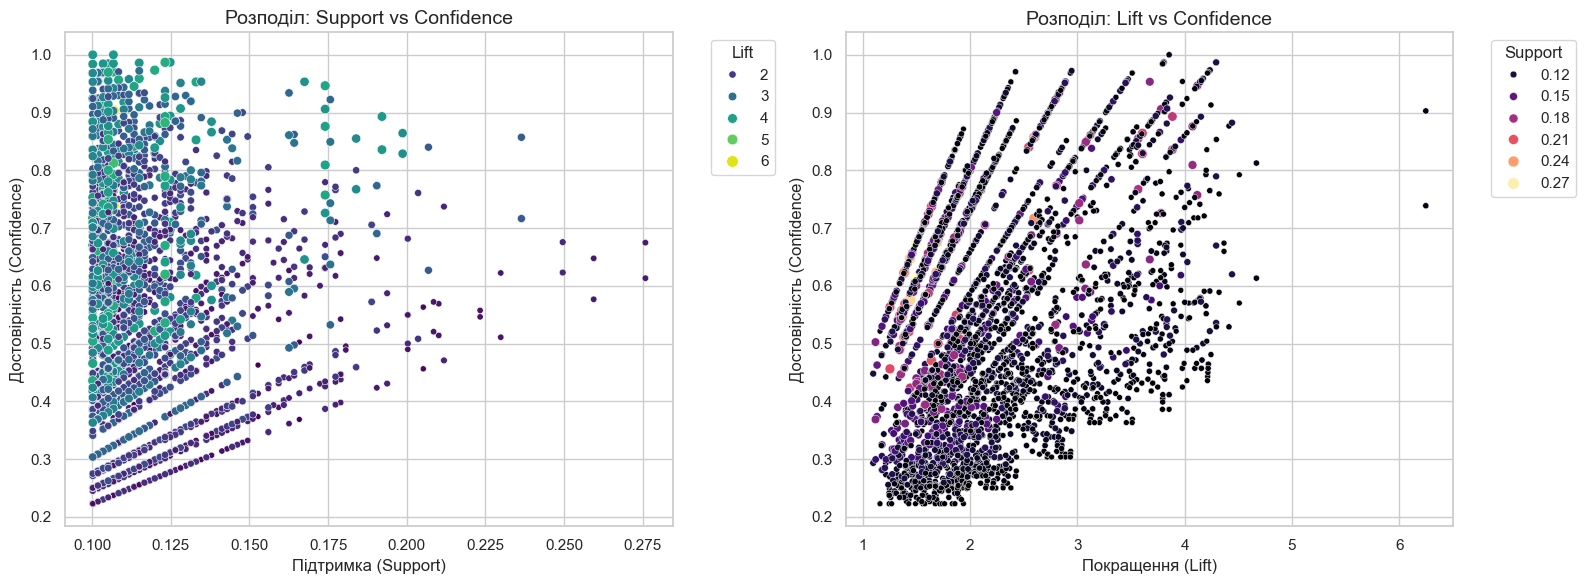

In [16]:
sns.set(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Графік Support vs Confidence
sns.scatterplot(x="support", y="confidence", size="lift", hue="lift", data=rules, palette="viridis", ax=ax1)
ax1.set_title("Розподіл: Support vs Confidence", fontsize=14)
ax1.set_xlabel("Підтримка (Support)")
ax1.set_ylabel("Достовірність (Confidence)")
ax1.legend(title="Lift", bbox_to_anchor=(1.05, 1), loc="upper left")

# 2. Графік Lift vs Confidence
sns.scatterplot(x="lift", y="confidence", size="support", hue="support", data=rules, palette="magma", ax=ax2)
ax2.set_title("Розподіл: Lift vs Confidence", fontsize=14)
ax2.set_xlabel("Покращення (Lift)")
ax2.set_ylabel("Достовірність (Confidence)")
ax2.legend(title="Support", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [17]:
# Очищення
if os.path.exists("tmp/ml-latest-small.zip"):
    os.remove("tmp/ml-latest-small.zip")
if os.path.exists("tmp/ml-latest-small"):
    shutil.rmtree("tmp/ml-latest-small")

### Аналіз та висновки

Для застосування у системах рекомендацій можна використати правила з високим Lift та Confidence, взявши за основу попередню активність користувача (переглянуті фільми, оцінки, відгуки). Для неперсоналізованих рекомендацій можна використати метрику support, яка вказує на найпопулярніші тайтли.

Збільшення `min_support` приводить до того, що в статистику потрапляють лише блокбастери, водночас сильне зменшення призводить до більшої кількості нішевих фільмів, проте також збільшується кількість шуму (випадкові правила, що не мають логіки).

Зміна `min_confidence` фактично є регулюванням того, наскільки "консервативним" є алгоритм. Чим він більший, тим менше фільмів рекомендується, проте точність буде вищою, водночас при низькому `min_confidence` ми жертвуємо точністю задля більшого різноманіття.

## Особистий висновок

Попри те, що використані в даній роботі параметри можуть бути досить точними, вони не передають настрої користувачів і не враховують їх особливості. Наприклад, тут не враховується час перегляду, середня оцінка користувача, історія перегляду тощо. Якщо користувач рідко ставить відгуки, або більш прискіпливий (оцінки >=4 є рідкістю), алгоритм не матиме змоги підібрати рекомендації.